<a href="https://colab.research.google.com/github/Yuvraj6085/cnnpro/blob/main/Face_Recognition_and_Emotion_Detection_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image


In [2]:
import kagglehub


path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013


In [3]:
import os


for root, dirs, files in os.walk(path):
    print(root)
    for file in files:
        print("   └──", file)


Streaming output truncated to the last 5000 lines.
   └── Training_71717074.jpg
   └── Training_83349364.jpg
   └── Training_8224205.jpg
   └── Training_69103613.jpg
   └── Training_7098848.jpg
   └── Training_38129729.jpg
   └── Training_95151390.jpg
   └── Training_66874071.jpg
   └── Training_23294249.jpg
   └── Training_86508875.jpg
   └── Training_50691325.jpg
   └── Training_26593901.jpg
   └── Training_81451115.jpg
   └── Training_39982194.jpg
   └── Training_18980574.jpg
   └── Training_39446205.jpg
   └── Training_9457008.jpg
   └── Training_6020903.jpg
   └── Training_21992204.jpg
   └── Training_92578622.jpg
   └── Training_61529099.jpg
   └── Training_67326933.jpg
   └── Training_39457045.jpg
   └── Training_4433687.jpg
   └── Training_39160872.jpg
   └── Training_66460314.jpg
   └── Training_80567356.jpg
   └── Training_83239385.jpg
   └── Training_56432944.jpg
   └── Training_37503027.jpg
   └── Training_94007114.jpg
   └── Training_56642897.jpg
   └── Training_57854102.j

In [4]:
train_dir = os.path.join(path, "train")
test_dir = os.path.join(path, "test")

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [5]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical'
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [8]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')  # Changed to 7 emotions to match the data
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=25
)

model.save("facetrack_emotion_model.h5")
print("✅ Model Saved Successfully!")


Epoch 1/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.2501 - loss: 1.8108

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


449/449 ━━━━━━━━━━━━━━━━━━━━ 225s 496ms/step - accuracy: 0.2501 - loss: 1.8106 - val_accuracy: 0.3898 - val_loss: 1.5818
Epoch 2/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 121s 270ms/step - accuracy: 0.3906 - loss: 1.5704 - val_accuracy: 0.4571 - val_loss: 1.4488
Epoch 3/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 123s 274ms/step - accuracy: 0.4437 - loss: 1.4369 - val_accuracy: 0.4939 - val_loss: 1.3219
Epoch 4/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 123s 274ms/step - accuracy: 0.4877 - loss: 1.3464 - val_accuracy: 0.5084 - val_loss: 1.2841
Epoch 5/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 120s 266ms/step - accuracy: 0.5041 - loss: 1.3008 - val_accuracy: 0.5291 - val_loss: 1.2358
Epoch 6/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 123s 273ms/step - accuracy: 0.5344 - loss: 1.2331 - val_accuracy: 0.5297 - val_loss: 1.2233
Epoch 7/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 120s 268ms/step - accuracy: 0.5447 - loss: 1.2032 - val_accuracy: 0.5451 - val_loss: 1.1838
Epoch 8/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 122s 273ms/step - accuracy: 0.5582 - loss: 1.16

✅ Model Saved Successfully!


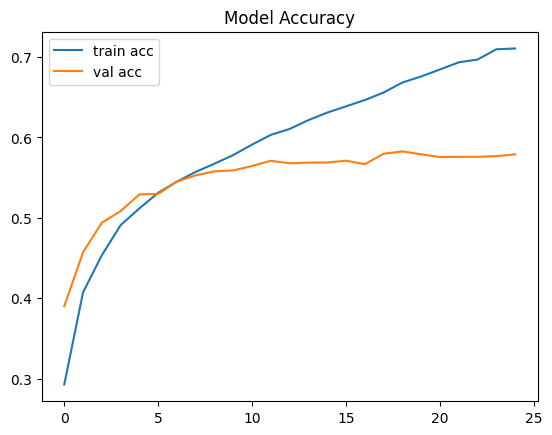

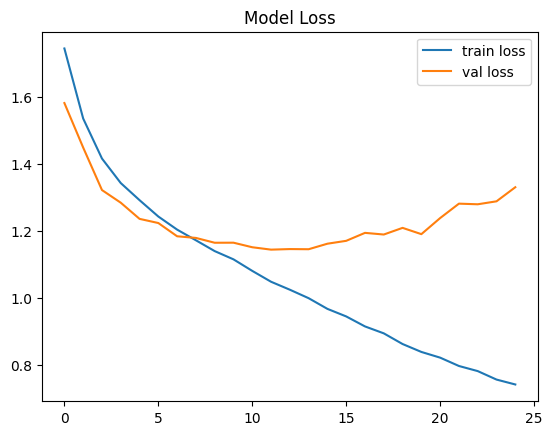

In [10]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Model Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Model Loss')
plt.legend()
plt.show()


In [11]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from google.colab.patches import cv2_imshow  # for showing images in Colab


In [16]:
model = load_model("facetrack_emotion_model.h5")

emotion_dict = {0: "Angry", 1: "Disgusted", 2: "Fearful", 3: "Happy", 4: "Neutral", 5: "Sad", 6: "Surprised"}

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [12]:
from IPython.display import Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = '📸 Capture Photo';
      div.appendChild(capture);
      document.body.appendChild(div);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture click
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      video.remove();
      const data = canvas.toDataURL('image/jpeg', quality);
      return data;
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename


<IPython.core.display.Javascript object>

Photo captured: photo.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


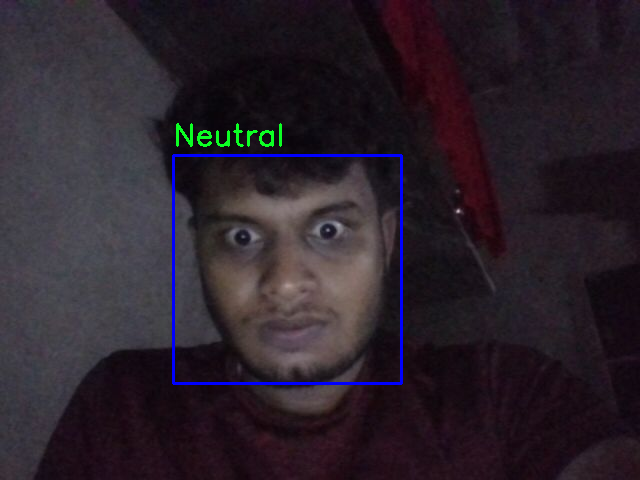

In [22]:
# Capture photo
filename = take_photo()
print("Photo captured:", filename)

# Load the image
frame = cv2.imread(filename)
gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray_frame, 1.3, 5)

for (x, y, w, h) in faces:
    roi_gray = gray_frame[y:y+h, x:x+w]
    roi_gray = cv2.resize(roi_gray, (48, 48))
    roi = roi_gray.reshape(1, 48, 48, 1) / 255.0

    prediction = model.predict(roi)
    emotion = emotion_dict[np.argmax(prediction)]

    cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
    cv2.putText(frame, emotion, (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (36,255,12), 2)

# Show image with emotion label
cv2_imshow(frame)
cv2.waitKey(0)
cv2.destroyAllWindows()
